In [1]:
#Time series mini project with real world data 

In [2]:
#Example : - Visuallising Seatle bicyle counts 

In [3]:
import pandas as pd 
data = pd.read_csv('FremontBridge.csv',index_col = 'Date' , parse_dates = True)

C:\Users\Monu Verma\AppData\Local\Temp\ipykernel_27116\2831115204.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data = pd.read_csv('FremontBridge.csv',index_col = 'Date' , parse_dates = True)


In [4]:
data.head()

,Fremont Bridge Total,Fremont Bridge East Sidewalk,Fremont Bridge West Sidewalk
Date,,,
2019-11-01 00:00:00,12.0,7.0,5.0
2019-11-01 01:00:00,7.0,0.0,7.0
2019-11-01 02:00:00,1.0,0.0,1.0
2019-11-01 03:00:00,6.0,6.0,0.0
2019-11-01 04:00:00,6.0,5.0,1.0


In [5]:
data.columns = ['Total','East','West']

In [6]:
data

,Total,East,West
Date,,,
2019-11-01 00:00:00,12.0,7.0,5.0
2019-11-01 01:00:00,7.0,0.0,7.0
2019-11-01 02:00:00,1.0,0.0,1.0
2019-11-01 03:00:00,6.0,6.0,0.0
2019-11-01 04:00:00,6.0,5.0,1.0
...,...,...,...
2021-12-31 19:00:00,0.0,0.0,0.0
2021-12-31 20:00:00,0.0,0.0,0.0
2021-12-31 21:00:00,0.0,0.0,0.0


In [8]:
data.dropna().describe()

,Total,East,West
count,147255.000000,147255.000000,147255.000000
mean,110.341462,50.077763,60.263699
std,140.422051,64.634038,87.252147
min,0.000000,0.000000,0.000000
25%,14.000000,6.000000,7.000000
50%,60.000000,28.000000,30.000000
75%,145.000000,68.000000,74.000000
max,1097.000000,698.000000,850.000000


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns 

Text(0, 0.5, 'hourly bicycle count')

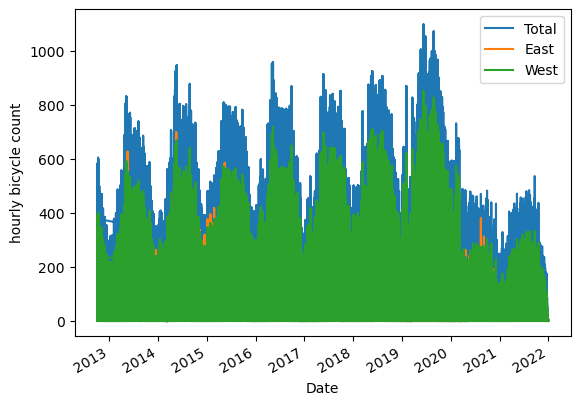

In [13]:
data.plot()
plt.ylabel('hourly bicycle count')

Text(0, 0.5, 'weekly bicycle counts')

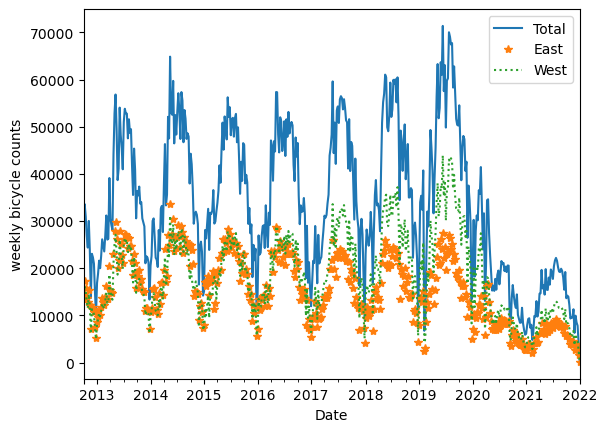

In [15]:
#this data is too dense tooo make sense out of it 
#lets resample this data by weeks 
week = data.resample('W').sum()
week.plot(style=['-','*',':'])
plt.ylabel('weekly bicycle counts')

In [16]:
#we can see that in 2020 or 21 it was too much decreased mainly it was because of the covid 19 effect that sudden dip in the data of 2021 or 22 which was the lowest 

In [17]:
#lets see the 30 days means by using the rolling function 

In [18]:
daily = data.resample('D').sum()

Text(0, 0.5, 'mean hourly count')

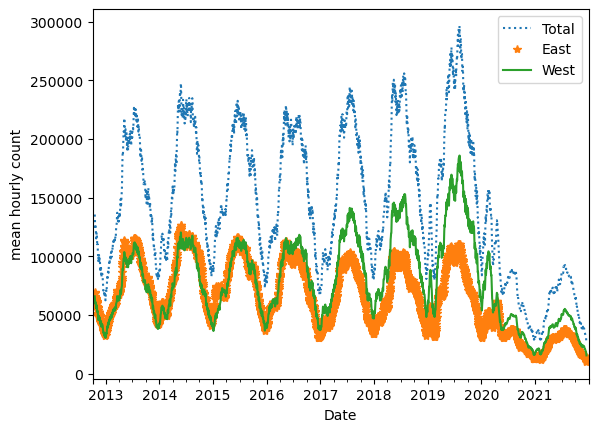

In [20]:
daily.rolling(30,center = True ).sum().plot(style=[':','*','-'])
plt.ylabel('mean hourly count')

<Axes: xlabel='Date'>

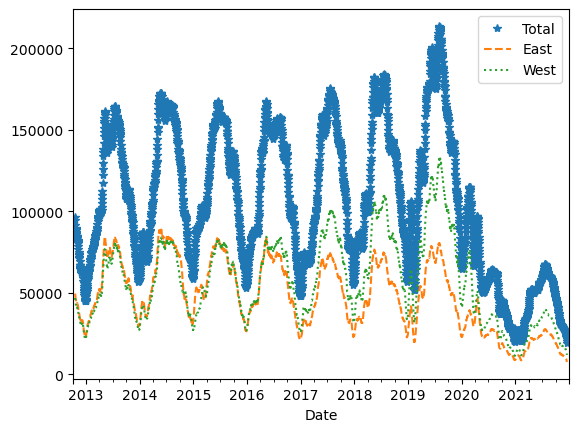

In [22]:
#more smoother version of the rolling window - gaussian window  
daily.rolling(30,center = True , win_type = 'gaussian' ).sum(std= 10 ).plot(style=['*','--',':'])

<Axes: xlabel='time'>

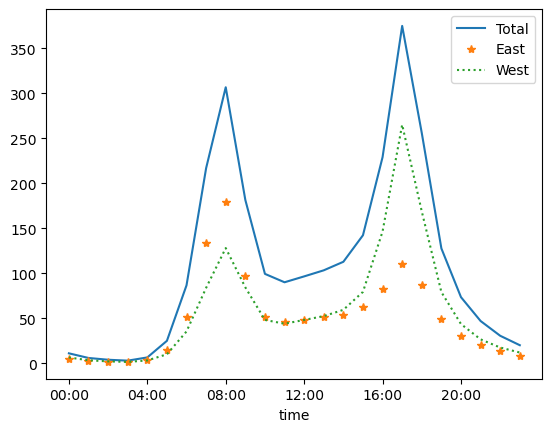

In [26]:
import numpy as np
#average hourly count bicycle counts 
by_time = data.groupby(data.index.time).mean()
hourly_ticks = 4*60*60*np.arange(6)

by_time.plot(xticks = hourly_ticks , style = ['-','*',':'])

<Axes: >

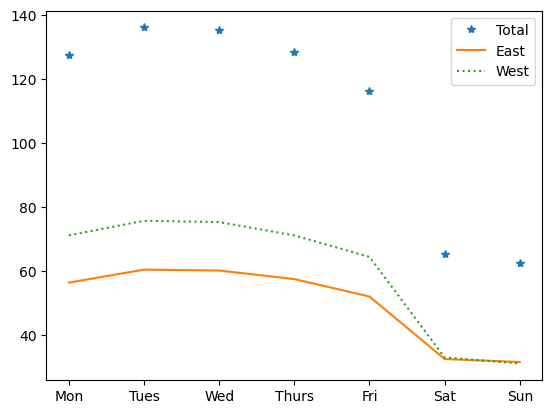

In [27]:
#lets see the trafic on the basis of the days of the week 
by_days = data.groupby(data.index.dayofweek).mean()
by_days.index = ['Mon', 'Tues', 'Wed', 'Thurs', 'Fri', 'Sat', 'Sun']
by_days.plot(style=['*','-',':'])